## Simple Regression Model
It is a supervised Learning algorithm used to model the relationship between one independent variable(X) and one dependent variable(y).

In [1]:
import pandas as pd

df = pd.read_csv("cleaned_data.csv") #Loading the data

#view the first 5 rows to  check the data loaded well
df.head(10)


,Duration,Date,Pulse,Maxpulse,Calories
0,60,'2020/12/01',110,130,409.1
1,60,'2020/12/02',117,145,479.0
2,60,'2020/12/03',103,135,340.0
3,45,'2020/12/04',109,175,282.4
4,45,'2020/12/05',117,148,406.0
5,60,'2020/12/06',102,127,300.0
6,60,'2020/12/07',110,136,374.0
7,450,'2020/12/08',104,134,253.3
8,30,'2020/12/09',109,133,195.1
9,60,'2020/12/10',98,124,269.0


In [2]:
#Step 2: Separating the Model

x = df[["Duration","Pulse","Maxpulse"]] #Features: Inputs

y = df["Calories"] #Target: Outputs



In [3]:
#Step 3 : Train Linear regression
from sklearn.linear_model import LinearRegression

#Create model
model = LinearRegression()

#Train the model
model.fit(x, y)


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


Predicting the Calories based on other Columns

In [4]:
#Making the prediction
predictions = model.predict(x)

display(predictions[:5])



array([330.51210211, 371.23176757, 312.10960094, 379.06040781,
       376.33999859])

## "In the real world, proper model training requires splitting data into training and testing sets rather than training on all the data, which can lead to overfitting"

In [5]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state =42)

model = LinearRegression()

#Train the Model
model.fit(x_train, y_train)

#Predict the Model/Testing the Model
predictions = model.predict(x_test)
display(predictions)

array([302.54853596, 279.55381859, 302.93617919, 240.09047181,
       344.01465058, 284.57761285])

## PLot Actual vs Predicted

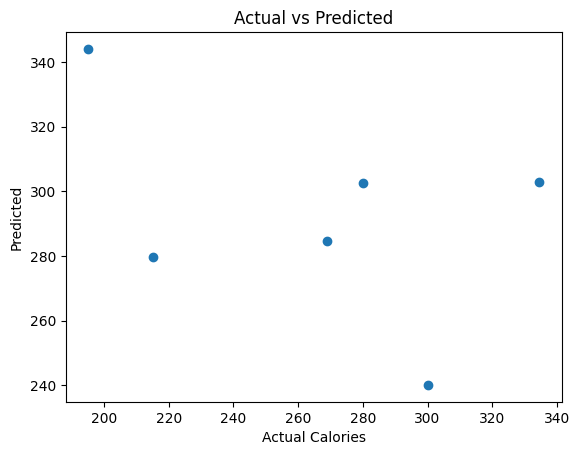

In [6]:
import matplotlib.pyplot as plt

plt.scatter(y_test,predictions)
plt.xlabel("Actual Calories")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")
plt.show()

In [7]:
from sklearn.metrics import r2_score

display("R2 Score:", r2_score(y_test, predictions))

'R2 Score:'

-1.3172590883750863

## R^2 close to 1 - strong Model
## R^2 around 0 - Weak model
## R^2 negative - very poor model

## Day 9:  Metrics
A metric is a numerical measurement used to judge how well a model performs.
Without metrics, you cannot say whether your model is good or bad.Training a model without evaluation is meaningless.

In Machine learning:
- You train a model- It makes predictions.
- You compare predictions to actual values.
- The difference between them is called error.
- The metrics summarizes those errors into a single number.

In [11]:
from sklearn.metrics import mean_absolute_error , mean_squared_error
import numpy as np

mae = mean_absolute_error(y_test, predictions) #Mean Absolute Error

mse = mean_squared_error(y_test,predictions) #Mean Squared Error

rmse = np.sqrt(mse)

print("MAE:", mae)
print("MSE:", mse)
print("RNSE:", rmse)



MAE: 57.14466116369561
MSE: 5275.585328816819
RNSE: 72.6332246896475


## MAE - Mean Absolute Error
Average of absolute differences between actual and predicted.
It does not heavily punish large errors.

MAE = 57 calories  means on average, my model are off by about 57 calories.



## MSE - Mean Squared Error
Penalizes large mistakes more heavily.


## RMSE - Root Mean Squared Error
Typical size of prediction error, but with heavy penalty for large errors.
My RMSE(72) is noticeably higher than MAE (57) meaning I likely have some larger errors (outlieers) in my predictions.

If RMSE = MSE,Errors are consistent
if RMSE > MAE, some predictions are  very wrong

My difference (72 vs 57) suggest variance in error size.


